In [23]:

import pickle
import os
import yaml
from pathlib import Path
from config.config import Config
import numpy as np
import matplotlib.pyplot as plt
import DecayFitNet.python.toolbox.BayesianDecayAnalysis as bda
from DecayFitNet.python.toolbox.DecayFitNetToolbox import DecayFitNetToolbox

from slope2noise.utils import schroeder_backward_int, decay_kernel, calculate_amplitudes_least_squares, octave_filtering

Here we are testing that we can retrive the correct EDC parameters from the RIRs generated using rir_synthesis.py


In [24]:
config_file = 'config/rir_synthesis_coupled_room_single_batch_gds.yml'
# Resolve the relative file path
file_path = Path(config_file).resolve()

# Read and parse the YAML file
with open(file_path, 'r') as file:
    config_data = yaml.safe_load(file)

config_dict = Config(**config_data)


In [25]:
i_batch = 0
batch_path = os.path.join(config_dict.output_dir, f"bb_wgn_{i_batch:04}.pkl")
with open(batch_path, 'rb') as f:
    RIRs = pickle.load(f)

n_rirs = RIRs.rir.shape[0]
i_rir = 60
time_axis = np.arange(0, RIRs.rir.shape[1]) / config_dict.fs

### Target Energy Decay Curve 
Construct the EDC of the desired RIR from the T_s and A_s values

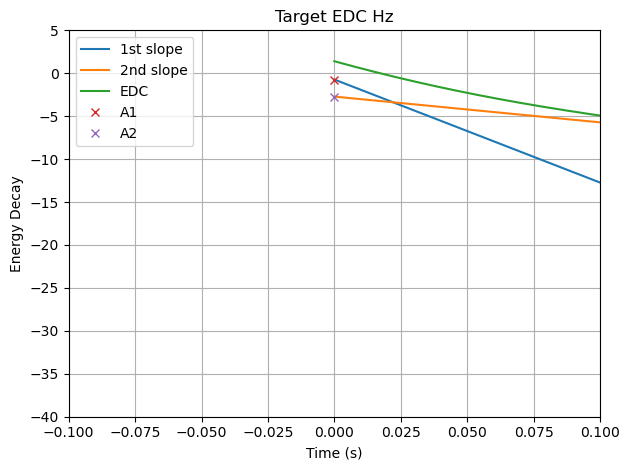

In [29]:
envelope_kernel = decay_kernel( np.transpose(np.array(RIRs.t_vals)),
                                time_axis,
                                config_dict.fs,
                                normalise_envelope=False,
                                add_noise=False)
edc = RIRs.a_vals[i_rir]*envelope_kernel

plt.plot(time_axis, 10*np.log10(edc[0, :, 0]), label='1st slope')
plt.plot(time_axis, 10*np.log10(edc[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), label='EDC')
plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.title(f'Target EDC Hz')
plt.ylim([-40, 5])
plt.xlim([-0.1, 0.1])
plt.grid(True)

plt.tight_layout()
plt.show()

### Shaped Noise
Here the Schroeder T and A values are adapted and used to define the envelopes, which are then multiplied with the wgn


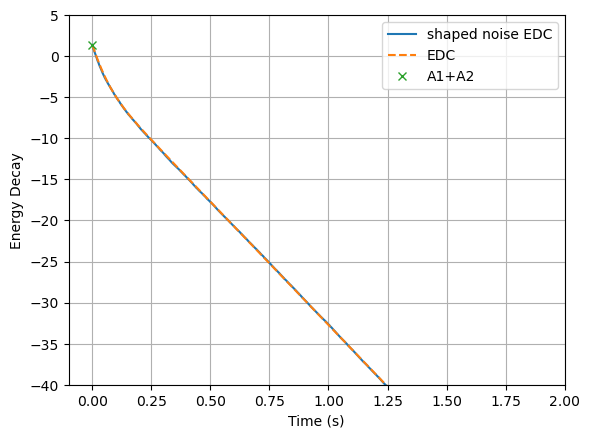

In [33]:
sn_int = schroeder_backward_int(RIRs.rir[i_rir, :], normalize=False)
# TODO: apply filter bank and sum the bands to get the EDC

plt.plot(time_axis, 10*np.log10(sn_int), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), '--', label='EDC')
plt.plot(0, 10*np.log10(RIRs.a_vals[i_rir, 0]+RIRs.a_vals[i_rir, 1]), 'x', label='A1+A2')
plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.ylim([-40, 5])
plt.xlim([-0.1, 2])
plt.grid(True)
plt.show()